In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

# Configuración de estilo global para las gráficas
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

def avg_power_to_pulse_power(avg_power, frequency, t_pulse, area):
  """
  :param avg_power: Potencia total incidente promedio del láser en Watts
  :param frequency: Frecuencia del láser en Hertz
  :param t_pulse: Tiempo del pulso en segundos
  :param area: Área efectiva de la superficie reflejante del DMD en cm^2
  :return: Densidad de potencia pico del láser en W / cm^2 (= Potencia de pulso / área del DMD)
  """

  # Energía por pulso
  e_pulse = avg_power / frequency

  # Potencia por pico
  p_pulse = e_pulse / t_pulse

  # Densidad de Potencia pico
  return p_pulse / area

def delta1_calc(q_m, t_pulse, alpha, k, avg_power):
  """
  :param q_m: Flujo de calor absorbido en la superficie reflejante en W / m^2 (q_m = PP * (1 - MR))
  :param t_pulse: Tiempo de pulso en picosegundos
  :param alpha: Difusividad térmica del espejo en m^2/s
  :param k: Conductividad térmica del espejo en W/m C
  :param avg_power: Potencia promedio del láser en Watts
  :return: Cambio máximo en la temperatura de la superficie del DMD débido al calor absorbido por la superficie
  reflejante, i.e, temperatura de la superficie reflejante al final de un pulso (Mirror surface to Bulk mirror Delta).

  T(t) = T_i + 2q_m ((alpha X t / PI)^(1/2) / k)
  """

  # 1. Arreglo de tiempo de t=0 a t=t_pulse (Malla del eje x para un pulso)
  t1_fs = np.linspace(0, t_pulse, 500)
  t1_s_arr = t1_fs * 1e-15

  # 2. Ecuación de sólido semi-infinito con T_i = 0
  T1 = 2 * q_m * np.sqrt((alpha * t1_s_arr) / np.pi) / k

  # 3. Gráfica de la temperatura en la superficie como función del tiempo durante el tiempo del pulso
  fig1, ax1 = plt.subplots(figsize=(8, 5))
  ax1.plot(t1_fs, T1, color='#D95319', linewidth=2, label='10.8 $\\mu$m pixel')
  ax1.set_xlabel('Time [fs]')
  ax1.set_ylabel('Temperature [$^\\circ$C]')
  ax1.set_title(f'Delta 1: Surface to Bulk ({t_pulse} fs, {avg_power} mW)')
  ax1.set_xlim(0, t_pulse)
  ax1.grid(True, linestyle='--', alpha=0.6)
  ax1.legend(loc='upper left', frameon=True, edgecolor='black')
  plt.plot()

  # Temperatura en la superficie al final del pulso
  return T1[-1]

def delta2_calc(t_pulse_us, period_us, Tf, tau, frequency_KHz):
  """
  :param t_pulse_us: Tiempo del pulso en microsegundos
  :param period_us: Periodo del ciclo (t_on + t_off) en microsegundos
  :param Tf: Temperatura final teórica en t = inf (steady-state) en grados (Tf = Ti + Q_mirror X R_mirror_to_silicon)
  :param tau: Constante de tiempo térmica del espejo en microsegundos (tau = R_mirror_to_silicon X C_mirror)
  :param frequency_KHz: Frecuencia del láser en KHz (solo para gráficar)
  :return: Bulk mirror to silicon delta (calor transferido desde la superficie del DMD a la base de silicio). El valor
  estable se obtiene déspues de varios ciclos.

  T(t) = Tf + (Ti - Tf)exp(- t / tau) (Bulk mirror temperature rise equation)
  """
  t2_lista = [] # lista con los tiempos (eje x)
  T2_lista = [] # lista con las temperaturas (eje y)
  temp_actual = 0.0

  # variables de bucle
  cicle_number = 0
  max_cicle_number = 20 # Número máximo de ciclos

  not_threshold = True
  tolerance = 0.0000001  # Condición de tolerancia para alcanzar steady-state

  prev_peak_temp = 0
  temp_pico = 0

  while not_threshold and cicle_number < max_cicle_number :

    # Calculamos los límites de tiempo de cada intervalo para el ciclo actual
    t_inicio = cicle_number * period_us  # tiempo inicial del bucle actual
    t_pico = t_inicio + t_pulse_us  # tiempo final del pulso
    t_fin = t_inicio + period_us  # tiempo final del ciclo (t_i + t_on + t_off)

    # Aumento en temperatura durante el pulso
    t_cal = np.linspace(t_inicio, t_pico, 100)
    T_cal = Tf + (temp_actual - Tf) * np.exp(-(t_cal - t_inicio) / tau)
    temp_pico = T_cal[-1]   # temperatura pico al final del pulso

    # Enfriamiento durante el tiempo t_off
    t_enf = np.linspace(t_pico, t_fin, 500)
    T_enf = 0 + (temp_pico - 0) * np.exp(-(t_enf - t_pico) / tau)
    temp_actual = T_enf[-1]  # temperatura al final del periodo (heat+cooling)

    #print(f"Ciclo:{cicle_number+1}")
    #print(f"Temperatura pico:{temp_pico}")
    #print(f"Temperatura final:{temp_actual}")

    # Condición del ciclo
    if abs(prev_peak_temp - temp_pico) < tolerance:
        not_threshold = False
    else:
        prev_peak_temp = temp_pico
        cicle_number += 1

    # Concatenar a las listas principales (omitiendo el primer punto del enfriamiento para no duplicar)
    t2_lista.extend(t_cal); T2_lista.extend(T_cal)
    t2_lista.extend(t_enf[1:]); T2_lista.extend(T_enf[1:])

  # convertimos las listas a arrays y convertimos el tiempo a milisegundos para la gráfica
  t2 = np.array(t2_lista) / 1000
  T2 = np.array(T2_lista)

  fig2, ax2 = plt.subplots(figsize=(8, 5))
  ax2.plot(t2, T2, color='#D95319', linewidth=1.5, label='10.8 $\\mu$m pixel')
  ax2.set_xlabel('Time [ms]')
  ax2.set_ylabel('Temperature [$^\\circ$C]')
  ax2.set_title(f'Delta 2: Bulk to Silicon ({t_pulse_us*1e9:.1f} fs, {frequency_KHz} kHz Repetition)')
  ax2.set_xlim(0, (cicle_number+1) * period_us * 1e-6 * 1000)
  ax2.grid(True, linestyle='--', alpha=0.6)
  ax2.legend(loc='upper right', frameon=True, edgecolor='black')
  plt.plot()

  # temperatura pico al final de cada pulso
  return temp_pico

def delta3_calc(avg_power, alpha_DMD):
  """
  :param avg_power: Potencia optica incidente promedio del láser sobre el DMD en Watts
  :param alpha_DMD: Absortividad térmica del DMD (constante adimensional)
  :return: Aumento de temperatura debido a la carga térmica total sobre el silicio multiplicada por la resistencia
  térmica del paquete desde el silicio hasta la cerámica de la parte posterior del paquete (Silicon to Ceramic Delta).

  Tf = Q_silicon X R_silicon_to_ceramic
  """
  # Q_silicon = Q_electrical + Q_illumination
  # Q_illumination = alpha_DMD X Q_incident

  Q_absorbed_opt = avg_power * alpha_DMD
  Q_electrical = 1.8 # W
  R_silicon_ceramic = 0.5 # C/W

  # Aumento en la temperatura
  return (Q_electrical + Q_absorbed_opt) * R_silicon_ceramic

# ---------------------------------------------------------------------
# Cálculo del cambio en la temperatura del DMD débido a Múltiples Pulsos
# ---------------------------------------------------------------------

def DMD_Temp_change(t_pulse, frequency_KHz, avg_power_mW, dmd_length_mm):
  """
  :param t_pulse: Tiempo del pulso en picosegundos
  :param frequency_KHz: Frecuencia del láser en KHz
  :param avg_power_mW: Potencia total incidente promedio del láser en mW
  :param dmd_length_mm: Longitud de un microespejo cuadrado del DMD
  :return: Cambio total en la temperatura de la superficie del DMD en grados celcius basado en un modelo lineal de tres
  resistencias (tres "deltas" o aumentos de temperaturas).

  T_mirror_surface - T_ceramic = T_silicon_to_ceramic + T_bulk_mirror_to_silicon + T_mirror_surface_to_bulk_mirror
  """
  # Cambio de unidades
  frecuencia_Hz = frequency_KHz * 1e3 # en Hz
  avg_power = avg_power_mW * 1e-3 # en W

  t_pulse_s = t_pulse * 1e-15     # en segundos
  t_pulse_us = t_pulse_s * 1e6    # en microsegundos

  period_s = 1 / frecuencia_Hz  # Duty cycle (periodo del ciclo: t_on + t_off)
  period_us = period_s * 1e6  # tiempo del periodo en microsegundos

  # Parámetros del DMD (Información del Datashet)
  alpha = 6.4667e-5 # m^2/s (Difusividad térmica)
  k = 160 # W/m-C (Conductividad térmica)
  tau = 32.27  # Constante de tiempo térmica en microsegundos (us)
  pixel = 10.8e-4 # Longitud de un microespejo en micrómetros
  area_pixel_cm2 = pixel**2  # Área de cada microespejo

  # Parámetros del DMD (Tablas) para mirror pitch Pixel = 10.8 (en micrómetros)
  R_bulk_silicon = 3.39e5       # Resistencia térmica Espejo-Silicio (R_mirror_to_silicon)
  MR = 0.94                     # Reflectividad del espejo
  FF_on = 0.931                 # Factor de llenado en estado ON
  FF_off = 0.726                # Factor de llenado en estado OFF

  # Densidad de potencia pico
  area_cm2 = (dmd_length_mm*0.1)**2
  # Densidad de potencia pico
  potencia_pico_W_cm2 = avg_power_to_pulse_power(avg_power, frecuencia_Hz, t_pulse_s, area_cm2) # en W/cm^2
  potencia_pico_W_m2 = potencia_pico_W_cm2 * 10000  # en W/m^2

  # ---------------------------------------------------------------------
  # CÁLCULO Y GRÁFICA: DELTA 1 (T_mirror_surface_to_bulk_mirror)
  # ---------------------------------------------------------------------

  # Calor absorbido (q_m = PP * (1 - MR))
  q_m = potencia_pico_W_m2 * (1 - MR)
  delta1 = delta1_calc(q_m, t_pulse, alpha, k, avg_power_mW)

  # ---------------------------------------------------------------------
  # CÁLCULO Y GRÁFICA: DELTA 2 (T_bulk_mirror_to_silicon)
  # ---------------------------------------------------------------------

  # Tf = T_i Q_mirror X R_mirror_to_silicon
  # Q_mirror = (PP X (mirror_pitch)^2) X [FF_mirror X (1 - MR)]
  Q_mirror = (potencia_pico_W_cm2 * area_pixel_cm2) * (FF_on * (1 - MR))
  Tf = Q_mirror * R_bulk_silicon # Temperatura final del steady-state

  delta2 = delta2_calc(t_pulse_us, period_us, Tf, tau, frequency_KHz)

  # ---------------------------------------------------------------------
  # CÁLCULO: DELTA 3 (T_silicon_to_ceramic)
  # ---------------------------------------------------------------------

  # alpha_DMD = (1 - overfill) [FF_mirror_off (1 - MR) + (1 - FF_mirror_off)] + 2 alpha_window + overfill
  # overfill = 1 - Array area / Incident area
  # alpha_window = absorptivity of window single pass

  alpha_window = 0.007
  overfill = 0

  alpha_DMD = (1-overfill)*( FF_off*(1 - MR) + (1-FF_off)) + 2*alpha_window + overfill
  delta3 = delta3_calc(avg_power, alpha_DMD)


  print(f"Densidad de Potencia Pico Calculada: {potencia_pico_W_cm2/1e6:,.0f} MW/cm^2")
  print(f"\n-> Delta 1 T_mirror_surface_to_bulk_mirror : {delta1:.4f} °C")
  print(f"\n-> Delta 2 T_bulk_mirror_to_silicon :    {delta2:.5f} °C")
  print(f"\n-> Delta 3 T_silicon_to_ceramic :           {delta3:.4f} °C")
  print(f"\nGradiente total de temperatura: {(delta1 + delta2 + delta3):.2f} [°C]\n")

Densidad de Potencia Pico Calculada: 0 MW/cm^2

-> Delta 1 T_mirror_surface_to_bulk_mirror : 0.8439 °C

-> Delta 2 T_bulk_mirror_to_silicon :    16.71569 °C

-> Delta 3 T_silicon_to_ceramic :           1.9279 °C

Gradiente total de temperatura: 19.49 [°C]



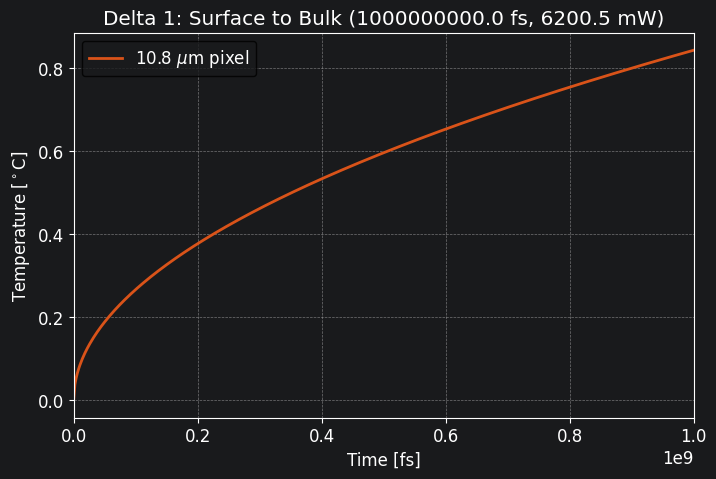

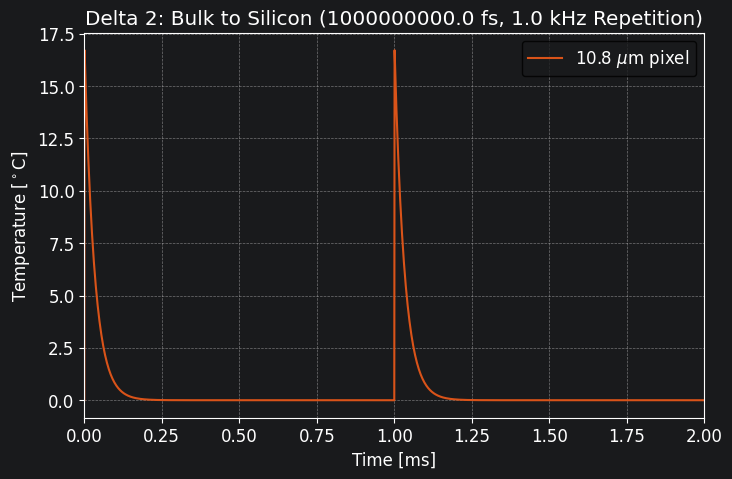

In [6]:
# Ejemplo 1 del artículo
# print(f"Densidad de Potencia Pico Calculada: {potencia_pico_W_cm2/1e3:,.0f} MW/cm^2")
DMD_Temp_change(1.0e9, 1.0, 6200.5, 5.0)

Densidad de Potencia Pico Calculada: 250 MW/cm^2

-> Delta 1 T_mirror_surface_to_bulk_mirror : 26.9010 °C

-> Delta 2 T_bulk_mirror_to_silicon :    1.79197 °C

-> Delta 3 T_silicon_to_ceramic :           1.9361 °C

Gradiente total de temperatura: 30.63 [°C]



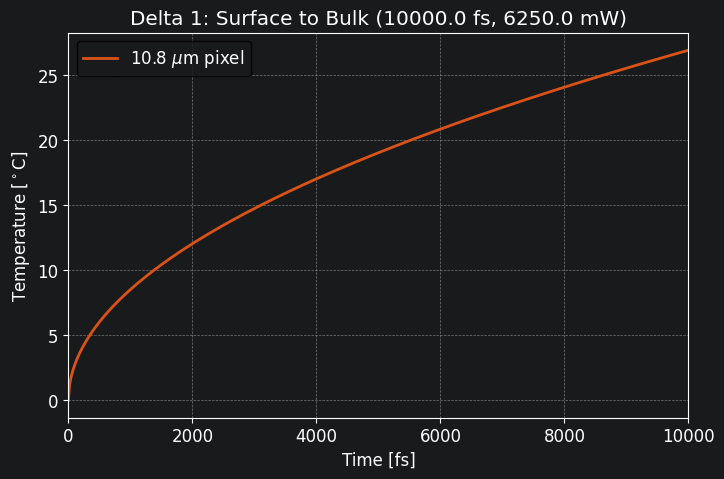

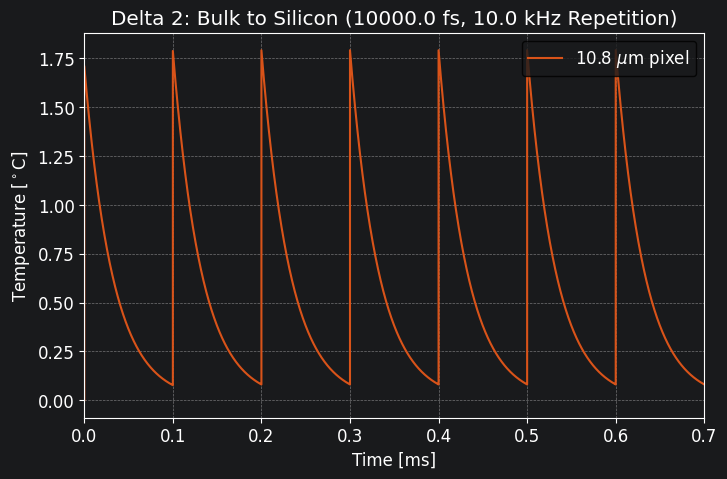

In [3]:
# Ejemplo 2 del artículo
# print(f"Densidad de Potencia Pico Calculada: {potencia_pico_W_cm2/1e6:,.0f} MW/cm^2")
DMD_Temp_change(10e3, 10.0, 6250.0, 5.0)

Densidad de Potencia Pico Calculada: 250 MW/cm^2

-> Delta 1 T_mirror_surface_to_bulk_mirror : 2.6901 °C

-> Delta 2 T_bulk_mirror_to_silicon :    0.01792 °C

-> Delta 3 T_silicon_to_ceramic :           0.9104 °C

Gradiente total de temperatura: 3.62 [°C]



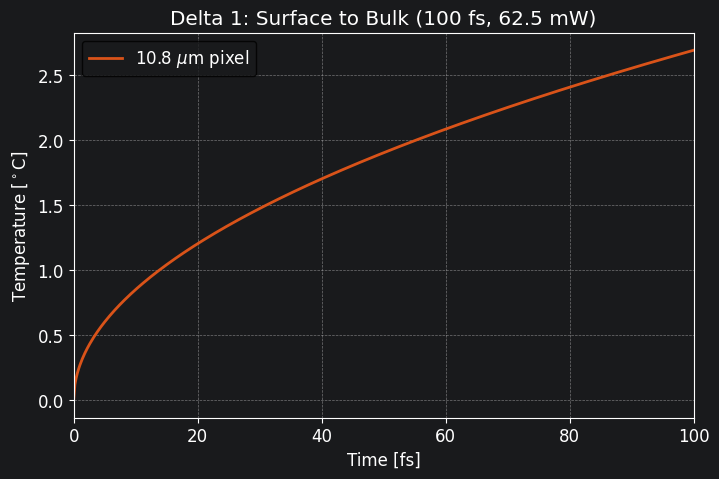

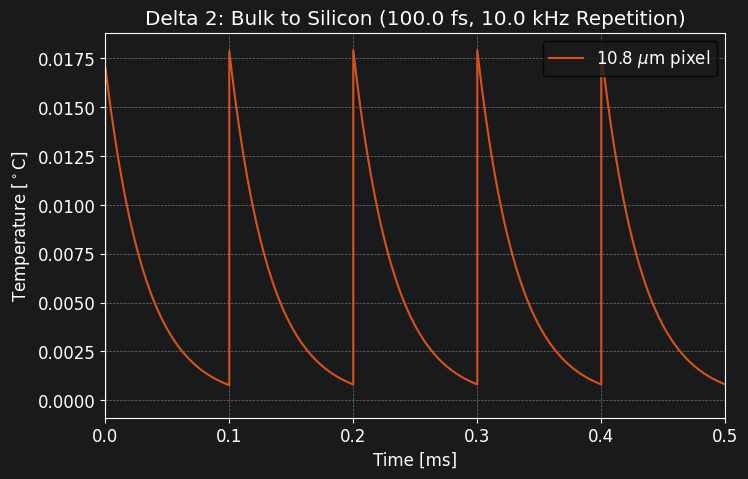

In [4]:
# Ejemplo 3 del artículo
# print(f"Densidad de Potencia Pico Calculada: {potencia_pico_W_cm2/1e6:,.0f} MW/cm^2")
DMD_Temp_change(100, 10.0, 62.5, 5.0)

Densidad de Potencia Pico Calculada: 16,000 MW/cm^2

-> Delta 1 T_mirror_surface_to_bulk_mirror : 172.1661 °C

-> Delta 2 T_bulk_mirror_to_silicon :    1.09514 °C

-> Delta 3 T_silicon_to_ceramic :           0.9663 °C

Gradiente total de temperatura: 174.23 [°C]



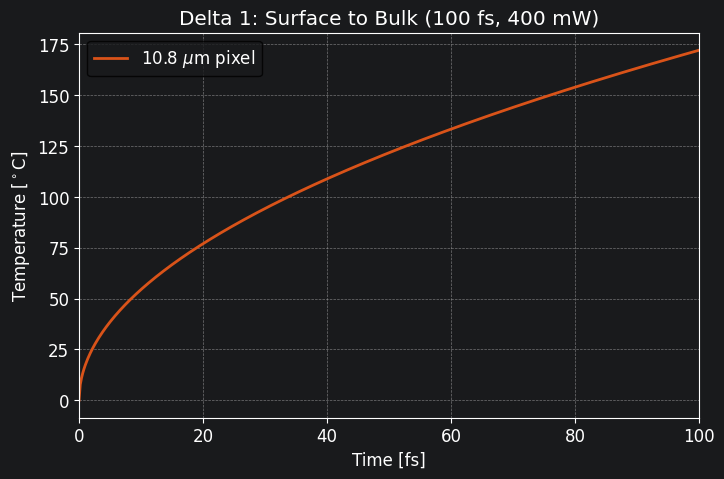

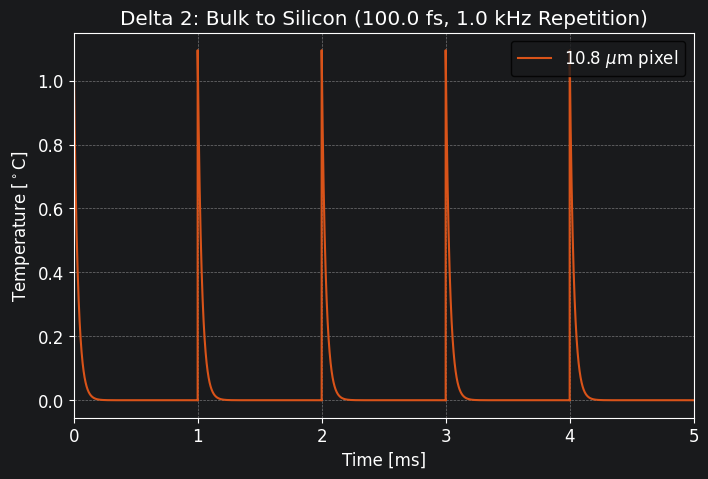

In [5]:
# Ejemplo clase: pulso de 100 picosegundos
DMD_Temp_change(100, 1.0, 400, 5.0)